In [1]:
from preprocessing.file_conversion import file_conversion
import numpy as np 

path = "/Users/reymendoza/Desktop/sleep_files"
X, X_scaled, y, groups = file_conversion(path)

Processing: sub-001_ses-001_task-sleep_acq-PSG_eeg.set
Reading /Users/reymendoza/Desktop/sleep_files/sub-001/ses-001/sub-001_ses-001_task-sleep_acq-PSG_eeg.fdt
Reading 0 ... 14255559  =      0.000 ... 28511.118 secs...
Creating RawArray with float64 data, n_channels=2, n_times=14255560
    Range : 0 ... 14255559 =      0.000 ... 28511.118 secs
Ready.
Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 49.38
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 49.12 Hz)
- Upper passband edge: 50.62 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 50.88 Hz)
- Filter length: 3301 samples (6.602 s)

  Feature matrix shape: (942, 50)
Processing: sub-001_ses-002_task-sleep_acq-PSG_ee

In [2]:
import numpy as np
np.savez_compressed("sleep_dataset_20_6_2.npz", X=X, X_scaled=X_scaled, y=y, groups=groups)

data = np.load("/Users/reymendoza/Developer/Sleep-Stage-Classification/sleep_dataset_20_6_2.npz", allow_pickle=True)
X = data["X"]
X_scaled = data["X_scaled"]
y = data["y"]
groups = data["groups"]


Class counts:
1     4601
2     5478
3    21138
Name: count, dtype: int64

Class proportions:
1    0.147
2    0.175
3    0.677
Name: proportion, dtype: float64

Fold 1/5


/Users/reymendoza/Developer/Sleep-Stage-Classification/.venv/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [08:39:44] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


accuracy=0.7739, balanced_accuracy=0.7600, f1_macro=0.7084

Fold 2/5


/Users/reymendoza/Developer/Sleep-Stage-Classification/.venv/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [08:39:48] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


accuracy=0.6153, balanced_accuracy=0.6703, f1_macro=0.5673

Fold 3/5


...

accuracy=0.8254, balanced_accuracy=0.8113, f1_macro=0.7861

Fold 4/5


/Users/reymendoza/Developer/Sleep-Stage-Classification/.venv/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [08:39:57] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


accuracy=0.7583, balanced_accuracy=0.7125, f1_macro=0.6840

Fold 5/5


/Users/reymendoza/Developer/Sleep-Stage-Classification/.venv/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [08:40:01] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


accuracy=0.8059, balanced_accuracy=0.7395, f1_macro=0.7419

Mean CV results:
accuracy: 0.7557
balanced_accuracy: 0.7387
precision_macro: 0.6960
recall_macro: 0.7387
f1_macro: 0.6975
precision_weighted: 0.8011
recall_weighted: 0.7557
f1_weighted: 0.7659
roc_auc_ovr_weighted: 0.8882

Classification report:
              precision    recall  f1-score   support

           1      0.504     0.849     0.632      4601
           2      0.634     0.583     0.608      5478
           3      0.891     0.776     0.830     21138

    accuracy                          0.753     31217
   macro avg      0.676     0.736     0.690     31217
weighted avg      0.789     0.753     0.761     31217


Row-normalized confusion matrix:
[[0.84916323 0.0291241  0.12171267]
 [0.1513326  0.58287696 0.26579043]
 [0.14301258 0.08070773 0.77627969]]


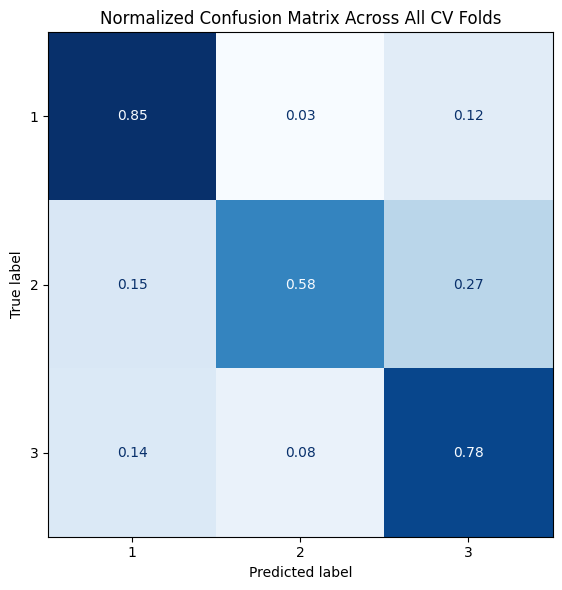

In [3]:
from metric_visualization import plot_normalized_confusion_matrix
from model import build_rf_model, build_xgb_model
from train import train, train_cnn, make_context_windows

def show_metrics(metrics):
    plot_normalized_confusion_matrix(
        cms=metrics["cms"],
        class_labels=metrics["class_labels"]
    )

model = build_xgb_model()

metrics = train(X, y, groups, model, smoothing=False, task='3-class')
show_metrics(metrics)


Class counts:
1     4601
2     5478
3     2504
4    13497
5     5137
Name: count, dtype: int64

Class proportions:
1    0.147
2    0.175
3    0.080
4    0.432
5    0.165
Name: proportion, dtype: float64

Fold 1/5


/Users/reymendoza/Developer/Sleep-Stage-Classification/.venv/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [08:40:05] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


accuracy=0.6784, balanced_accuracy=0.6592, f1_macro=0.6497

Fold 2/5


/Users/reymendoza/Developer/Sleep-Stage-Classification/.venv/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [08:40:12] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


accuracy=0.5923, balanced_accuracy=0.5861, f1_macro=0.5452

Fold 3/5


...

accuracy=0.7922, balanced_accuracy=0.7128, f1_macro=0.7069

Fold 4/5


/Users/reymendoza/Developer/Sleep-Stage-Classification/.venv/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [08:40:26] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


accuracy=0.6090, balanced_accuracy=0.6005, f1_macro=0.5751

Fold 5/5


/Users/reymendoza/Developer/Sleep-Stage-Classification/.venv/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [08:40:32] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


accuracy=0.6644, balanced_accuracy=0.5967, f1_macro=0.5977

Mean CV results:
accuracy: 0.6672
balanced_accuracy: 0.6310
precision_macro: 0.6296
recall_macro: 0.6310
f1_macro: 0.6149
precision_weighted: 0.7073
recall_weighted: 0.6672
f1_weighted: 0.6731
roc_auc_ovr_weighted: 0.8890

Classification report:
              precision    recall  f1-score   support

           1      0.515     0.823     0.634      4601
           2      0.673     0.591     0.629      5478
           3      0.278     0.298     0.288      2504
           4      0.800     0.678     0.734     13497
           5      0.794     0.766     0.780      5137

    accuracy                          0.668     31217
   macro avg      0.612     0.631     0.613     31217
weighted avg      0.693     0.668     0.673     31217


Row-normalized confusion matrix:
[[0.82264725 0.03760052 0.07628776 0.04977179 0.01369268]
 [0.15717415 0.59072654 0.11299744 0.12997444 0.00912742]
 [0.23202875 0.16853035 0.29792332 0.27755591 0.0239616

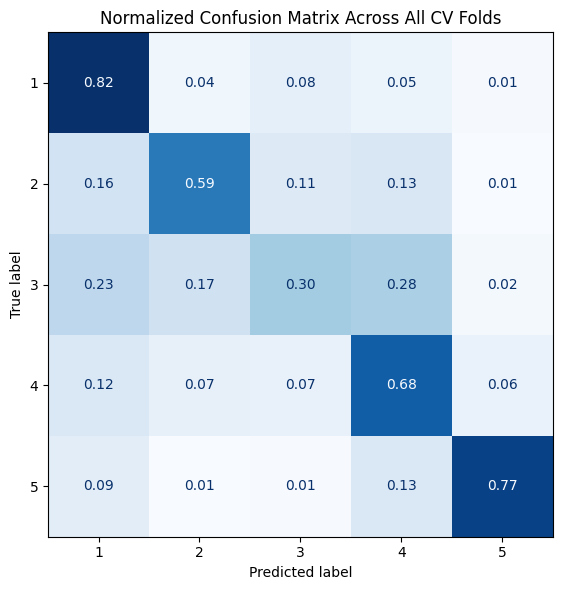

In [4]:
from metric_visualization import plot_normalized_confusion_matrix
from model import build_rf_model, build_xgb_model
from train import train, train_cnn, make_context_windows

def show_metrics(metrics):
    plot_normalized_confusion_matrix(
        cms=metrics["cms"],
        class_labels=metrics["class_labels"]
    )

model = build_xgb_model()

metrics = train(X, y, groups, model, task='5-class')
show_metrics(metrics)


Class counts:
1     4601
2     5478
3    21138
Name: count, dtype: int64

Class proportions:
1    0.147
2    0.175
3    0.677
Name: proportion, dtype: float64

Fold 1/5
accuracy=0.7719, balanced_accuracy=0.7083, f1_macro=0.6840

Fold 2/5
accuracy=0.7030, balanced_accuracy=0.7128, f1_macro=0.6315

Fold 3/5
accuracy=0.8372, balanced_accuracy=0.8267, f1_macro=0.7972

Fold 4/5
accuracy=0.7844, balanced_accuracy=0.7364, f1_macro=0.7129

Fold 5/5
accuracy=0.8197, balanced_accuracy=0.7424, f1_macro=0.7586

Mean CV results:
accuracy: 0.7832
balanced_accuracy: 0.7453
precision_macro: 0.7186
recall_macro: 0.7453
f1_macro: 0.7168
precision_weighted: 0.8081
recall_weighted: 0.7832
f1_weighted: 0.7878
roc_auc_ovr_weighted: 0.8998

Classification report:
              precision    recall  f1-score   support

           1      0.580     0.846     0.688      4601
           2      0.639     0.561     0.597      5478
           3      0.885     0.824     0.853     21138

    accuracy                  

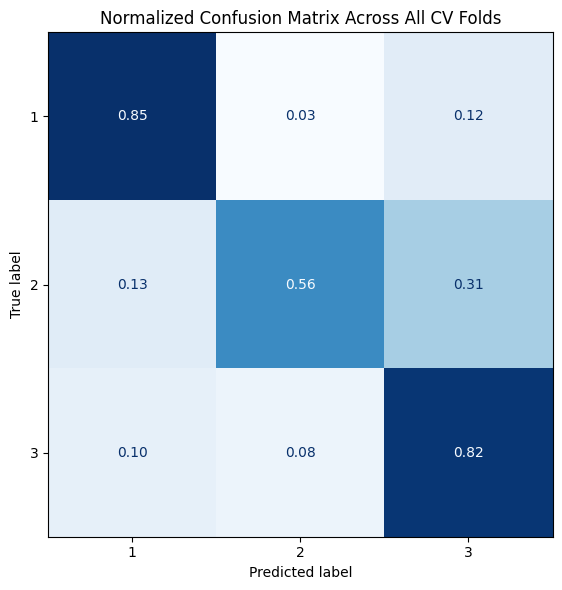

In [5]:
from metric_visualization import plot_normalized_confusion_matrix
from model import build_rf_model
from train import train, train_cnn, make_context_windows

def show_metrics(metrics):
    plot_normalized_confusion_matrix(
        cms=metrics["cms"],
        class_labels=metrics["class_labels"]
    )

model = build_rf_model()

metrics = train(X, y, groups, model, task='3-class')
show_metrics(metrics)


Class counts:
1     4601
2     5478
3     2504
4    13497
5     5137
Name: count, dtype: int64

Class proportions:
1    0.147
2    0.175
3    0.080
4    0.432
5    0.165
Name: proportion, dtype: float64

Fold 1/5
accuracy=0.6744, balanced_accuracy=0.6470, f1_macro=0.6319

Fold 2/5
accuracy=0.6197, balanced_accuracy=0.6017, f1_macro=0.5653

Fold 3/5
accuracy=0.7675, balanced_accuracy=0.6892, f1_macro=0.6876

Fold 4/5
accuracy=0.6296, balanced_accuracy=0.6118, f1_macro=0.5845

Fold 5/5
accuracy=0.6307, balanced_accuracy=0.5746, f1_macro=0.5716

Mean CV results:
accuracy: 0.6644
balanced_accuracy: 0.6249
precision_macro: 0.6167
recall_macro: 0.6249
f1_macro: 0.6082
precision_weighted: 0.6907
recall_weighted: 0.6644
f1_weighted: 0.6666
roc_auc_ovr_weighted: 0.8848

Classification report:
              precision    recall  f1-score   support

           1      0.561     0.835     0.672      4601
           2      0.672     0.553     0.607      5478
           3      0.257     0.280     0.2

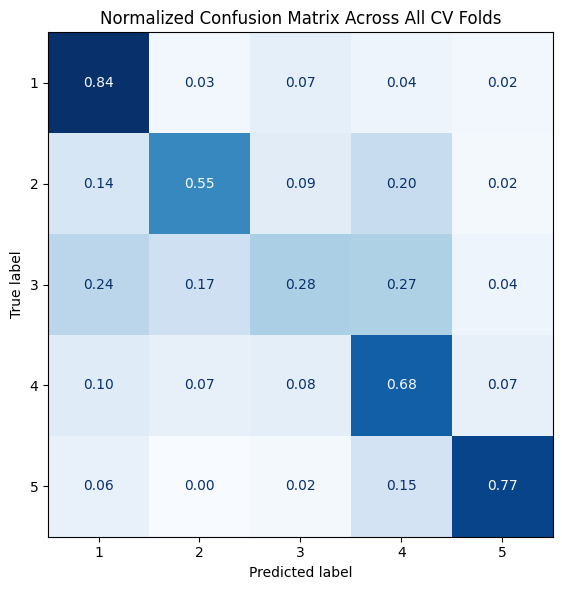

In [6]:
from metric_visualization import plot_normalized_confusion_matrix
from model import build_rf_model
from train import train, train_cnn, make_context_windows

def show_metrics(metrics):
    plot_normalized_confusion_matrix(
        cms=metrics["cms"],
        class_labels=metrics["class_labels"]
    )

model = build_rf_model()

metrics = train(X, y, groups, model, task='5-class')
show_metrics(metrics)

In [ ]:
from metric_visualization import plot_normalized_confusion_matrix
from model import build_rf_model
from train import train, make_context_windows, train_hybrid_cnn_lstm_attention_smoothed

def show_metrics(metrics):
    plot_normalized_confusion_matrix(
        cms=metrics["cms"],
        class_labels=metrics["class_labels"]
    )

metrics_h_3 = train_hybrid_cnn_lstm_attention_smoothed(X_scaled, X, y, groups, task='3-class')
show_metrics(metrics_h_3)


Class counts:
1     4568
2     5476
3    21133
Name: count, dtype: int64

Class proportions:
1    0.147
2    0.176
3    0.678
Name: proportion, dtype: float64

Fold 1/5



Class counts:
1    2021
2    2441
3    1182
4    5757
5    1952
Name: count, dtype: int64

Class proportions:
1    0.151
2    0.183
3    0.089
4    0.431
5    0.146
Name: proportion, dtype: float64

Fold 1/5
Epoch 1/20
322/322 ━━━━━━━━━━━━━━━━━━━━ 181s 527ms/step - accuracy: 0.3587 - loss: 1.4504 - val_accuracy: 0.5468 - val_loss: 1.1444 - learning_rate: 1.0000e-04
Epoch 2/20
322/322 ━━━━━━━━━━━━━━━━━━━━ 161s 499ms/step - accuracy: 0.4992 - loss: 1.1803 - val_accuracy: 0.5869 - val_loss: 1.0101 - learning_rate: 1.0000e-04
Epoch 3/20
322/322 ━━━━━━━━━━━━━━━━━━━━ 156s 485ms/step - accuracy: 0.5348 - loss: 1.0889 - val_accuracy: 0.6013 - val_loss: 0.9512 - learning_rate: 1.0000e-04
Epoch 4/20
322/322 ━━━━━━━━━━━━━━━━━━━━ 155s 481ms/step - accuracy: 0.5649 - loss: 1.0353 - val_accuracy: 0.6316 - val_loss: 0.9041 - learning_rate: 1.0000e-04
Epoch 5/20
322/322 ━━━━━━━━━━━━━━━━━━━━ 154s 479ms/step - accuracy: 0.5827 - loss: 0.9919 - val_accuracy: 0.6127 - val_loss: 0.9337 - learning_rate: 1.

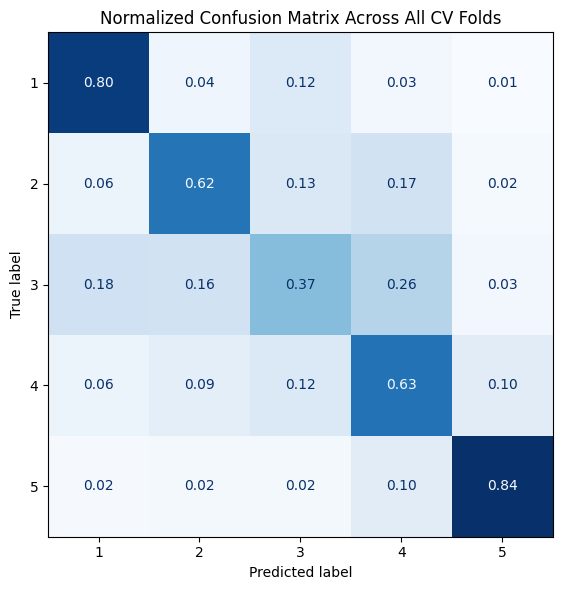

In [ ]:
def show_metrics(metrics):
    plot_normalized_confusion_matrix(
        cms=metrics["cms"],
        class_labels=metrics["class_labels"]
    )

metrics_h_5 = train_hybrid_cnn_lstm_attention_smoothed(X_scaled, X, y, groups, task='5-class')
show_metrics(metrics_h_5)